<a href="https://colab.research.google.com/github/Joboreh97/Codes-that-function/blob/main/phase_tracker_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase Tracker — Complete Analysis
## Master's Thesis: Kalman vs Neural Network Phase Tracking
### Run all cells top to bottom. Total time: ~90 minutes on Colab T4 GPU.

## CELL 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted.")

Mounted at /content/drive
Drive mounted.


## CELL 2 — Install dependencies and upload training script

In [2]:
# Check TensorFlow version
import tensorflow as tf
print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Upload nn_phase_tracker_v7_fair.py from your computer
# Run this cell, click 'Choose Files', select nn_phase_tracker_v7_fair.py
from google.colab import files
print()
print("Please upload nn_phase_tracker_v7_fair.py now:")
uploaded = files.upload()
for fn in uploaded.keys():
    print(f"  Uploaded: {fn}")

TensorFlow: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Please upload nn_phase_tracker_v7_fair.py now:


Saving nn_phase_tracker_v7_fair.py to nn_phase_tracker_v7_fair (1).py
  Uploaded: nn_phase_tracker_v7_fair (1).py


## CELL 3 — Set paths (edit RESULTS_DIR here)

In [3]:
import os

# ── EDIT THIS PATH to match your Google Drive folder ──────────────────────────
RESULTS_DIR = '/content/drive/MyDrive/Masterarbeit_Simulation_Results'

# Create the folder if it does not exist
os.makedirs(RESULTS_DIR, exist_ok=True)

NN_CONST_FILE   = os.path.join(RESULTS_DIR, 'nn_tracker_v7fair_const.npy')
NN_FAIR_RESULTS = os.path.join(RESULTS_DIR, 'nn_tracker_v7fair_results.npz')

print(f"Results dir:          {RESULTS_DIR}")
print(f"NN const file exists: {os.path.exists(NN_CONST_FILE)}")
print(f"NN results exists:    {os.path.exists(NN_FAIR_RESULTS)}")
print()
print("If both files already exist you can skip Cell 4 (training).")

Results dir:          /content/drive/MyDrive/Masterarbeit_Simulation_Results
NN const file exists: False
NN results exists:    False

If both files already exist you can skip Cell 4 (training).


## CELL 4 — Train NN Fair-v7 (skip if already trained)
**This takes ~35 minutes on T4 GPU.**
If you already have `nn_tracker_v7fair_const.npy` in your Drive, skip this cell.

In [4]:
import subprocess, sys

cmd = [
    sys.executable, 'nn_phase_tracker_v7_fair.py',
    '--mode',            'both',
    '--seq_length',      '1050',
    '--batch_size',      '16',
    '--epochs_s1',       '20',
    '--epochs_s2',       '80',
    '--num_mc',          '100',
    '--num_sym',         '1050',
    '--n_iter',          '3',
    '--pilot_spacing',   '51',
    '--nn_num_test',     '100',
    '--snr_min',         '10.0',
    '--snr_max',         '30.0',
    '--snr_steps',       '11',
    '--min_radius',      '0.50',
    '--beta_reg_weight', '0.05',
    '--beta_target',     '2.5',
    '--batches_per_epoch','50',
    '--lr_init',         '3e-4',
    '--results_dir',     RESULTS_DIR,
    '--filename',        'nn_tracker_v7fair',
]

print("Starting NN training...")
print("Command:", ' '.join(cmd))
print()

# Run and stream output line by line
process = subprocess.Popen(cmd, stdout=subprocess.PIPE,
                           stderr=subprocess.STDOUT, text=True)
for line in process.stdout:
    print(line, end='')
process.wait()
print()
print(f"Return code: {process.returncode}")
print(f"NN const saved: {os.path.exists(NN_CONST_FILE)}")
print(f"NN results saved: {os.path.exists(NN_FAIR_RESULTS)}")

Streaming output truncated to the last 5000 lines.
  [S1] Ep   5/20  B  50/50  loss=0.00242  ETA: 4m 20s
  [S1] Ep   5/20  loss=0.00201  elapsed=1m 26s
  [S1] Ep   6/20  B   1/50  loss=0.00196  ETA: 4m 19s
  [S1] Ep   6/20  B   2/50  loss=0.00163  ETA: 4m 19s
  [S1] Ep   6/20  B   3/50  loss=0.00174  ETA: 4m 18s
  [S1] Ep   6/20  B   4/50  loss=0.00164  ETA: 4m 18s
  [S1] Ep   6/20  B   5/50  loss=0.00175  ETA: 4m 17s
  [S1] Ep   6/20  B   6/50  loss=0.00208  ETA: 4m 17s
  [S1] Ep   6/20  B   7/50  loss=0.00168  ETA: 4m 17s
  [S1] Ep   6/20  B   8/50  loss=0.00237  ETA: 4m 16s
  [S1] Ep   6/20  B   9/50  loss=0.00176  ETA: 4m 16s
  [S1] Ep   6/20  B  10/50  loss=0.00186  ETA: 4m 15s
  [S1] Ep   6/20  B  11/50  loss=0.00184  ETA: 4m 15s
  [S1] Ep   6/20  B  12/50  loss=0.00210  ETA: 4m 14s
  [S1] Ep   6/20  B  13/50  loss=0.00140  ETA: 4m 14s
  [S1] Ep   6/20  B  14/50  loss=0.00157  ETA: 4m 14s
  [S1] Ep   6/20  B  15/50  loss=0.00190  ETA: 4m 13s
  [S1] Ep   6/20  B  16/50  loss=0.001

## CELL 5 — Imports and helper functions

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ── Phase noise parameters ─────────────────────────────────────────────────────
L2_100_DBC = -80.0
L2_INF_DBC = -120.0
F3DB_KHZ   = 10.0
FS_MHZ     = 10.0

# ── Simulation parameters ──────────────────────────────────────────────────────
SNR_MIN       = 10.0
SNR_MAX       = 30.0
SNR_STEPS     = 11
NUM_MC        = 100
NUM_SYM       = 1050
N_ITER        = 3
PILOT_SPACING = 51

def build_pn_params():
    l2_100   = 10**(L2_100_DBC/10)
    l2_inf   = 10**(L2_INF_DBC/10)
    f_3dB    = F3DB_KHZ * 1e3
    Ts       = 1.0 / (FS_MHZ * 1e6)
    sigma_c2 = (np.pi * 1e10 * l2_100) / f_3dB
    sigma_f2 = l2_inf / Ts
    a_pn     = np.exp(-2*np.pi*f_3dB*Ts)
    sigma_u2 = sigma_c2 * (1 - a_pn**2)
    return dict(l2_100=l2_100, l2_inf=l2_inf, f_3dB=f_3dB, Ts=Ts,
                sigma_c2=sigma_c2, sigma_f2=sigma_f2, a_pn=a_pn, sigma_u2=sigma_u2)

pn = build_pn_params()

def generate_phase_noise(N, pn):
    tc    = np.zeros(N)
    tc[0] = np.random.normal(0, np.sqrt(pn['sigma_c2']))
    for k in range(1, N):
        tc[k] = pn['a_pn']*tc[k-1] + np.random.normal(0, np.sqrt(pn['sigma_u2']))
    return tc + np.random.normal(0, np.sqrt(pn['sigma_f2']), N)

def compute_beta(c):
    return float(np.mean(1.0/np.abs(c)**2))

def closed_form(snr_db, pn, beta=1.0):
    sw2   = 1.0/10**(snr_db/10)
    num   = 2*1e10*pn['l2_100']
    denom = beta*sw2*pn['Ts'] + 2*pn['l2_inf']
    ft    = np.sqrt(pn['f_3dB']**2 + num/denom)
    return (num/ft)*np.arctan(1.0/(2*pn['Ts']*ft)) + pn['l2_inf']/pn['Ts']

snr_dbs   = np.linspace(SNR_MIN, SNR_MAX, SNR_STEPS)
theory_b1 = np.array([closed_form(s, pn, 1.0) for s in snr_dbs])

print(f"sigma_c2 = {pn['sigma_c2']:.4e} rad^2")
print(f"sigma_f2 = {pn['sigma_f2']:.4e} rad^2/sample")
print(f"a_pn     = {pn['a_pn']:.6f}")
print(f"SNR range: {SNR_MIN}-{SNR_MAX} dB  ({SNR_STEPS} points)")

sigma_c2 = 3.1416e-02 rad^2
sigma_f2 = 1.0000e-05 rad^2/sample
a_pn     = 0.993737
SNR range: 10.0-30.0 dB  (11 points)


## CELL 6 — Constellation definitions

In [6]:
def generate_qam(M):
    K=int(np.sqrt(M)); lv=np.arange(-(K-1),K,2)
    c=np.array([complex(i,q) for i in lv for q in lv])
    return c/np.sqrt(np.mean(np.abs(c)**2))

def generate_psk(M):
    c=np.exp(1j*2*np.pi*np.arange(M)/M)
    return c/np.sqrt(np.mean(np.abs(c)**2))

def generate_64apsk_dvbs2():
    r=[1.0,2.53,3.70,4.64]; ns=[4,12,20,28]; c=[]
    for ri,ni in zip(r,ns):
        off=np.pi/ni if ri==r[0] else (np.pi/12 if ni==12 else 0)
        for k in range(ni): c.append(ri*np.exp(1j*(2*np.pi*k/ni+off)))
    c=np.array(c); return c/np.sqrt(np.mean(np.abs(c)**2))

def generate_64apsk_dvbs2x():
    r=[1.0,2.84,4.32,5.27]; ns=[4,12,20,28]; c=[]
    for ri,ni in zip(r,ns):
        off=np.pi/ni if ri==r[0] else (np.pi/12 if ni==12 else 0)
        for k in range(ni): c.append(ri*np.exp(1j*(2*np.pi*k/ni+off)))
    c=np.array(c); return c/np.sqrt(np.mean(np.abs(c)**2))

def generate_64apsk_gray():
    c=[]
    for ri,r in enumerate([1.0,2.2,3.2,4.2]):
        off=np.pi/16 if ri%2==1 else 0
        for k in range(16): c.append(r*np.exp(1j*(2*np.pi*k/16+off)))
    c=np.array(c); return c/np.sqrt(np.mean(np.abs(c)**2))

def generate_spiral(M, fs=0.0):
    c=[]
    for m in range(1,M+1):
        A=(4*np.pi*m)**2*fs/2; B=4*np.pi*m
        t=np.sqrt(A+np.sqrt(A**2+B**2)); c.append(t*np.exp(1j*t))
    c=np.array(c); return c/np.sqrt(np.mean(np.abs(c)**2))

def generate_star64():
    c=[]
    for k in range(8):
        arm=2*np.pi*k/8
        for i,r in enumerate(0.25*(2.8/0.25)**(np.arange(8)/7)):
            c.append(r*np.exp(1j*(arm+0.03*np.sin(i*np.pi/4))))
    c=np.array(c); return c/np.sqrt(np.mean(np.abs(c)**2))

def generate_ring_init(M=64, n_rings=4, noise=0.02, seed=42):
    np.random.seed(seed)
    pts_per_ring = M // n_rings
    radii = np.linspace(0.75, 1.25, n_rings)
    pts = []
    for i, r in enumerate(radii):
        offset = np.pi * i / (n_rings * pts_per_ring)
        for k in range(pts_per_ring):
            pts.append(r * np.exp(1j*(2*np.pi*k/pts_per_ring + offset)))
    c = np.array(pts, dtype=complex)
    c += noise * (np.random.randn(M) + 1j*np.random.randn(M))
    c /= np.sqrt(np.mean(np.abs(c)**2))
    return c

constellations = {
    '8-PSK':      generate_psk(8),
    '16-QAM':     generate_qam(16),
    '64-QAM':     generate_qam(64),
    'APSK-S2':    generate_64apsk_dvbs2(),
    'APSK-S2X':   generate_64apsk_dvbs2x(),
    'APSK-Gray':  generate_64apsk_gray(),
    'Spiral-fs0': generate_spiral(64, 0.0),
    'Spiral-PN':  generate_spiral(64, 0.005),
    'Star-64':    generate_star64(),
}

nn_const_init = generate_ring_init()

nn_const_trained = None
if os.path.exists(NN_CONST_FILE):
    nn_const_trained = np.load(NN_CONST_FILE)
    print(f"Loaded NN trained constellation: beta={compute_beta(nn_const_trained):.3f}")
else:
    print("NN constellation not found. Run Cell 4 first.")

print(f"Ring init: beta={compute_beta(nn_const_init):.3f}")
for name, c in constellations.items():
    print(f"  {name:12s}: {len(c):3d} pts  beta={compute_beta(c):.3f}")

Loaded NN trained constellation: beta=1.157
Ring init: beta=1.150
  8-PSK       :   8 pts  beta=1.000
  16-QAM      :  16 pts  beta=1.889
  64-QAM      :  64 pts  beta=2.685
  APSK-S2     :  64 pts  beta=2.019
  APSK-S2X    :  64 pts  beta=2.313
  APSK-Gray   :  64 pts  beta=2.868
  Spiral-fs0  :  64 pts  beta=2.409
  Spiral-PN   :  64 pts  beta=5.449
  Star-64     :  64 pts  beta=7.823


## CELL 7 — Constellation plots: all variants + NN before/after training

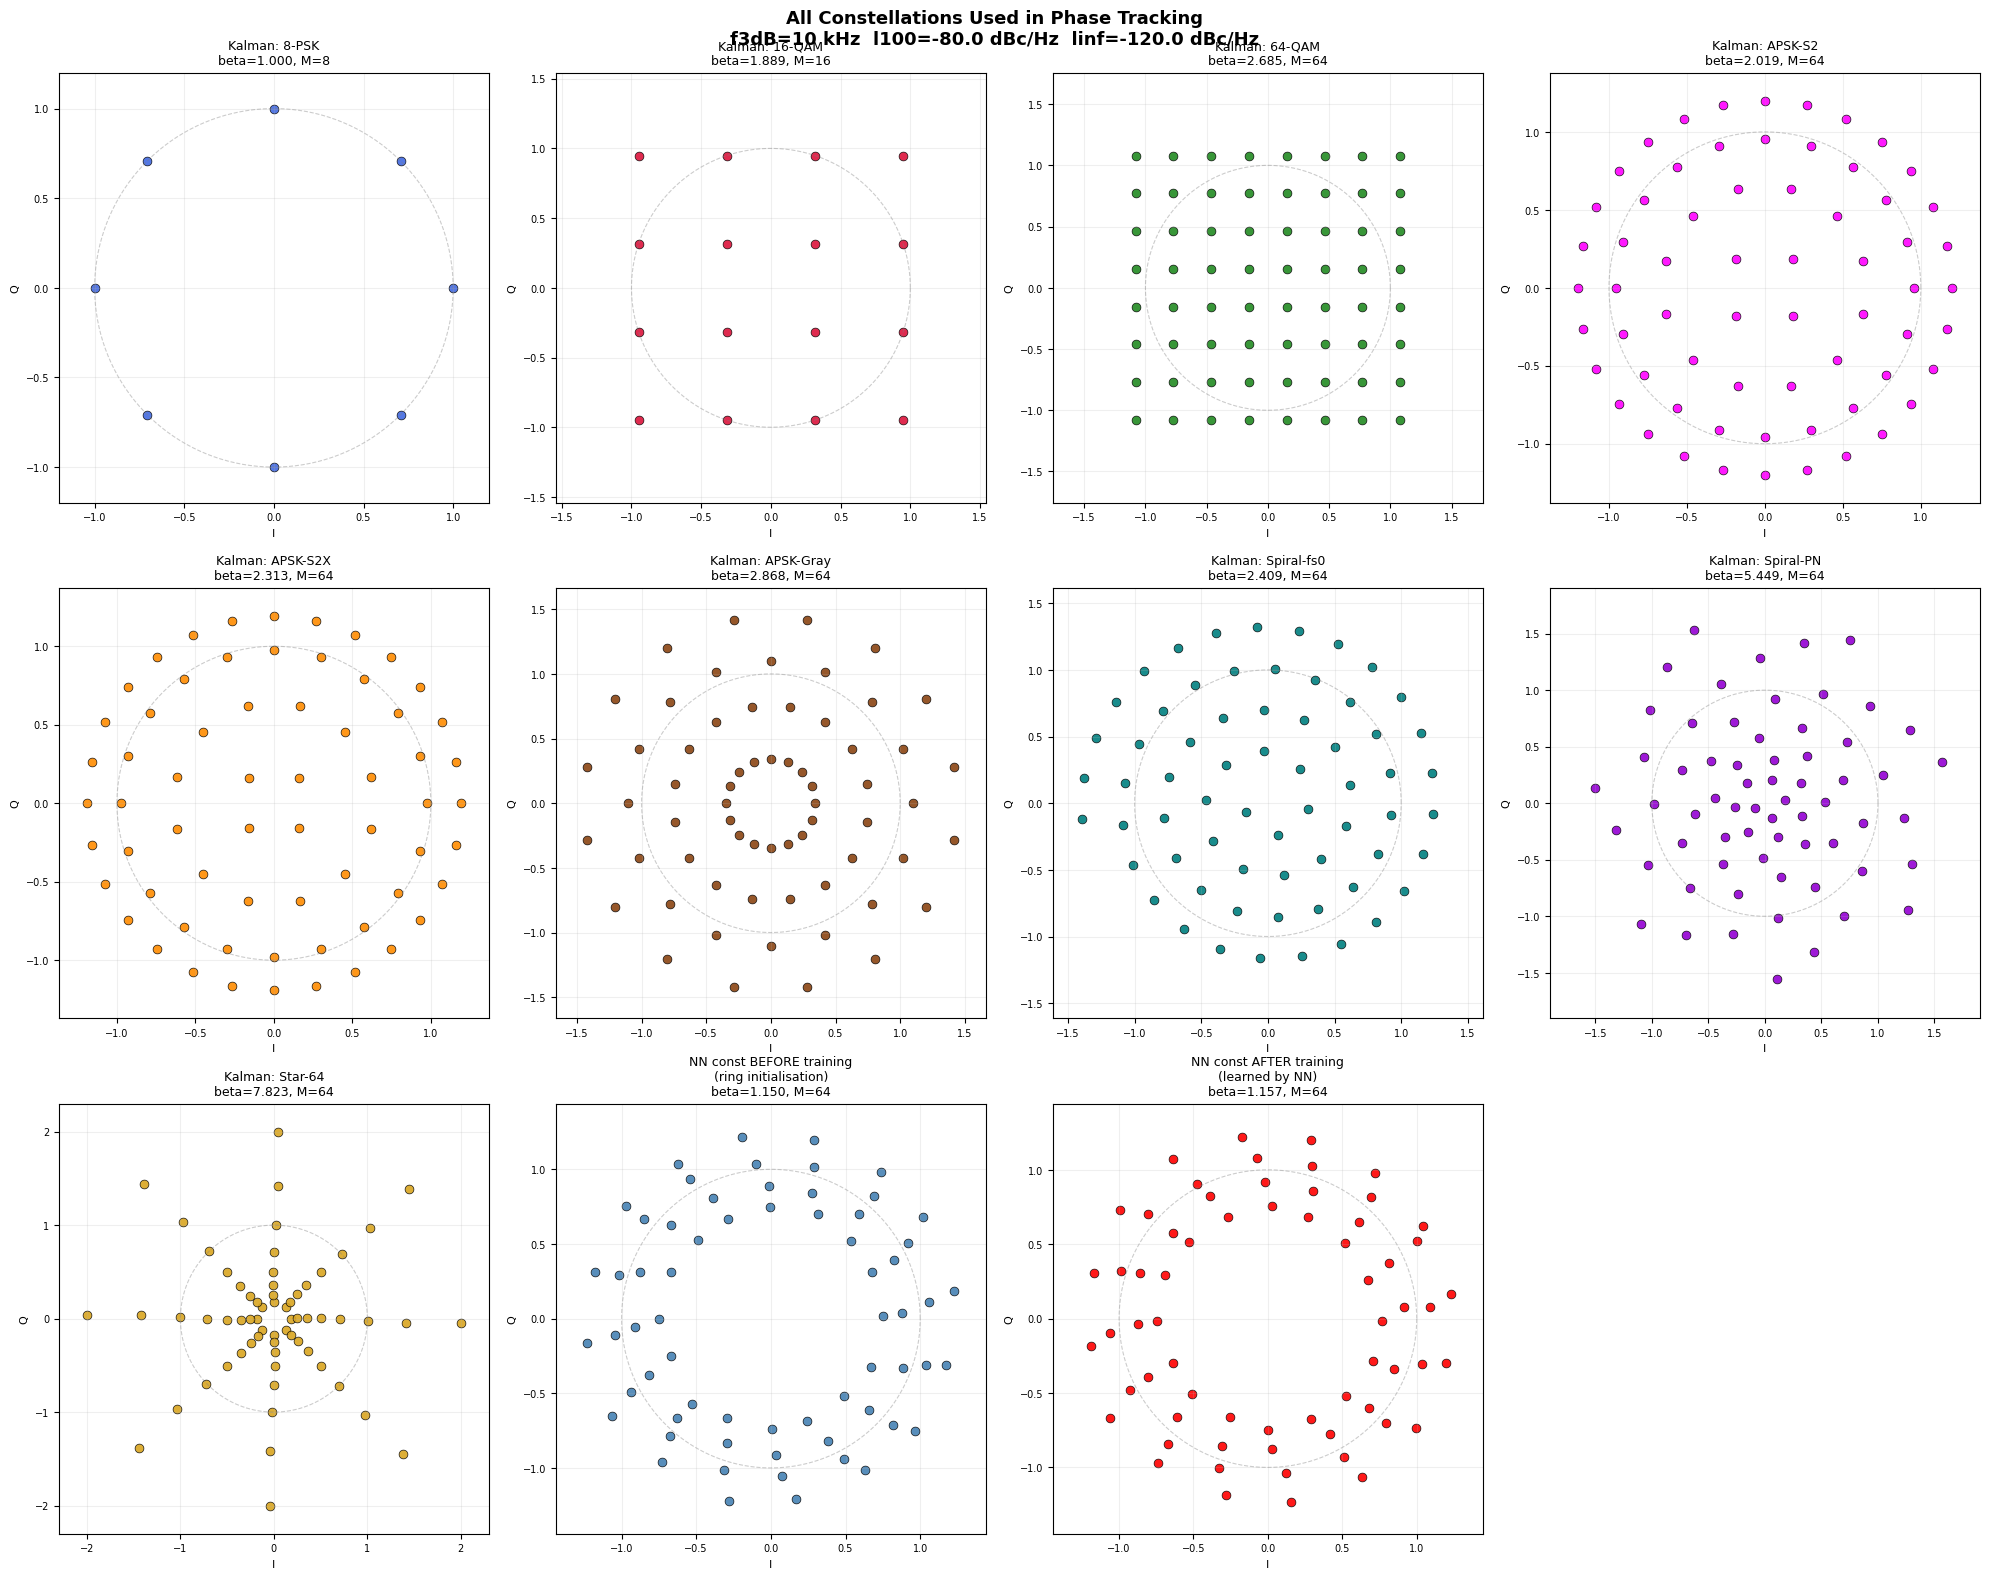

Saved: all_constellations.png


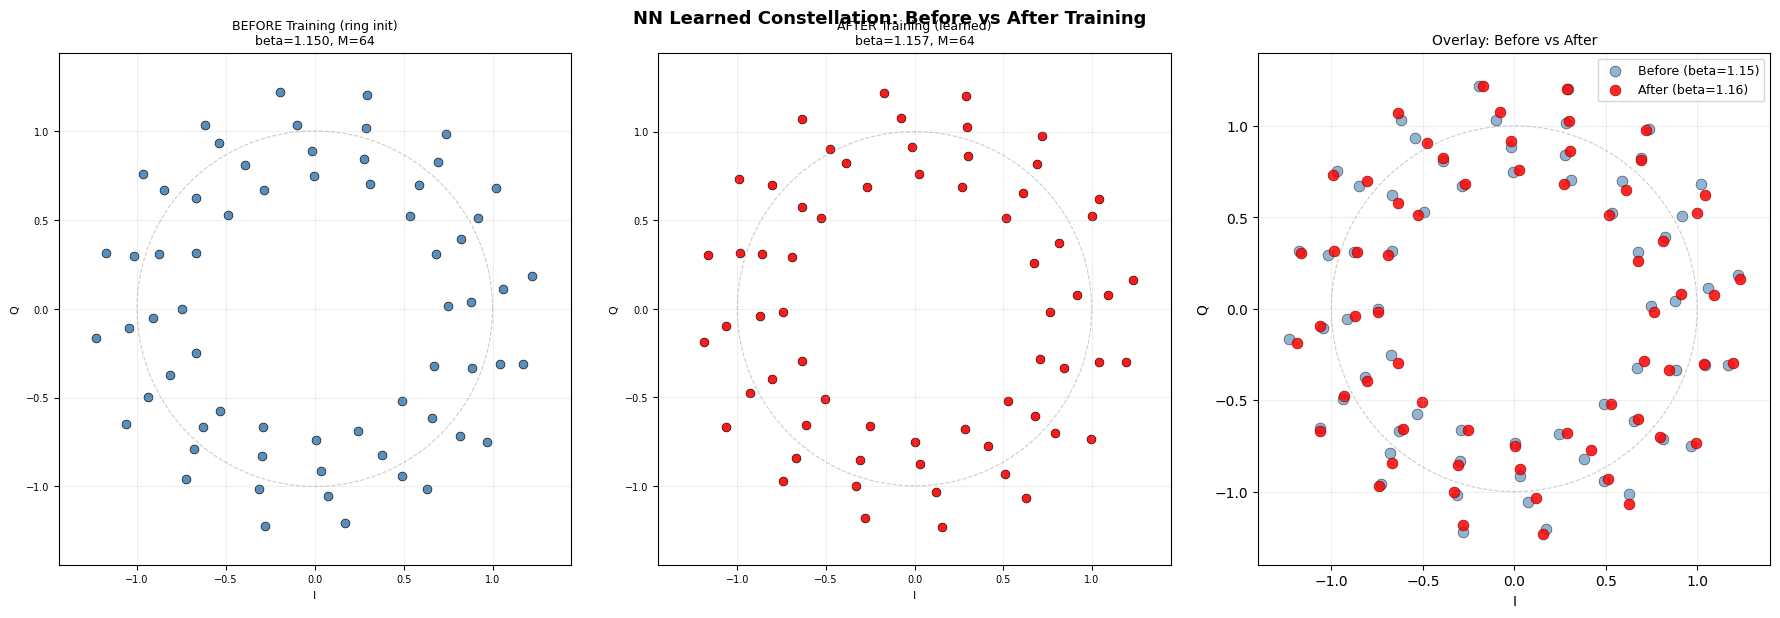

Saved: nn_constellation_before_after.png


In [7]:
def plot_constellation(ax, c, title, color='royalblue'):
    ax.scatter(c.real, c.imag, s=40, c=color, edgecolors='k', lw=0.5, alpha=0.9)
    th = np.linspace(0, 2*np.pi, 300)
    ax.plot(np.cos(th), np.sin(th), 'gray', lw=0.8, ls='--', alpha=0.4)
    mx = max(np.max(np.abs(c))*1.15, 1.2)
    ax.set_xlim([-mx,mx]); ax.set_ylim([-mx,mx]); ax.set_aspect('equal')
    ax.set_title(f'{title}\nbeta={compute_beta(c):.3f}, M={len(c)}', fontsize=9)
    ax.set_xlabel('I', fontsize=8); ax.set_ylabel('Q', fontsize=8)
    ax.tick_params(labelsize=7); ax.grid(True, alpha=0.2)

colors_list = ['royalblue','crimson','forestgreen','magenta',
               'darkorange','saddlebrown','teal','darkviolet','goldenrod']

# ── Plot 1: All constellations grid ───────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 16))
fig.suptitle('All Constellations Used in Phase Tracking\n'
             f'f3dB={F3DB_KHZ:.0f} kHz  l100={L2_100_DBC} dBc/Hz  linf={L2_INF_DBC} dBc/Hz',
             fontsize=13, fontweight='bold')

for idx, (name, c) in enumerate(constellations.items()):
    plot_constellation(axes[idx//4][idx%4], c, f'Kalman: {name}', colors_list[idx])

plot_constellation(axes[2][1], nn_const_init,
                   'NN const BEFORE training\n(ring initialisation)', 'steelblue')

if nn_const_trained is not None:
    plot_constellation(axes[2][2], nn_const_trained,
                       'NN const AFTER training\n(learned by NN)', 'red')
else:
    axes[2][2].text(0.5,0.5,'Train NN first\n(Cell 4)',
                    ha='center', va='center', transform=axes[2][2].transAxes, fontsize=11)
    axes[2][2].set_title('NN AFTER training', fontsize=9)

axes[2][3].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'all_constellations.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: all_constellations.png")

# ── Plot 2: NN before vs after side by side ────────────────────────────────────
fig, axes2 = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('NN Learned Constellation: Before vs After Training', fontsize=13, fontweight='bold')

plot_constellation(axes2[0], nn_const_init,
                   'BEFORE Training (ring init)', 'steelblue')

if nn_const_trained is not None:
    plot_constellation(axes2[1], nn_const_trained,
                       'AFTER Training (learned)', 'red')
    ax = axes2[2]
    ax.scatter(nn_const_init.real, nn_const_init.imag, s=60, c='steelblue',
               edgecolors='k', lw=0.5, alpha=0.6,
               label=f'Before (beta={compute_beta(nn_const_init):.2f})')
    ax.scatter(nn_const_trained.real, nn_const_trained.imag, s=60, c='red',
               edgecolors='darkred', lw=0.5, alpha=0.85,
               label=f'After (beta={compute_beta(nn_const_trained):.2f})')
    th = np.linspace(0,2*np.pi,300)
    ax.plot(np.cos(th),np.sin(th),'gray',lw=0.8,ls='--',alpha=0.4)
    ax.set_xlim([-1.4,1.4]); ax.set_ylim([-1.4,1.4]); ax.set_aspect('equal')
    ax.set_title('Overlay: Before vs After', fontsize=10)
    ax.legend(fontsize=9); ax.grid(True,alpha=0.2)
    ax.set_xlabel('I'); ax.set_ylabel('Q')
else:
    for a in axes2[1:]:
        a.text(0.5,0.5,'Train NN first',ha='center',va='center',
               transform=a.transAxes,fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'nn_constellation_before_after.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: nn_constellation_before_after.png")

## CELL 8 — Uncoded Kalman function

In [8]:
def simulate_kalman(snr_db, constellation, pn,
                    num_mc=NUM_MC, num_sym=NUM_SYM,
                    n_iter=N_ITER, pilot_spacing=PILOT_SPACING):
    """
    Uncoded Kalman smoother.
    Pass 1: pilot-based forward Kalman + backward smoother + linear interpolation.
    Passes 2-3: full symbol-by-symbol Kalman with DA decisions (pilots kept as x_true).
    """
    a=pn['a_pn']; sc2=pn['sigma_c2']; sf2=pn['sigma_f2']; su2=pn['sigma_u2']
    sw2=1.0/10**(snr_db/10); sw=np.sqrt(sw2)
    ps=pilot_spacing; ns=num_sym
    a_p=a**ps; su_p=sc2*(1-a_p**2); residuals=[]

    for _ in range(num_mc):
        x_true = np.random.choice(constellation, ns)
        ppos   = list(range(0, ns, ps)); np_ = len(ppos)
        theta_tot = generate_phase_noise(ns, pn)
        y = x_true*np.exp(1j*theta_tot)
        y += (np.random.normal(0,sw,ns)+1j*np.random.normal(0,sw,ns))/np.sqrt(2)

        # Pass 1: pilot-based forward Kalman
        fth=np.zeros(np_); fp=np.zeros(np_)
        pth=np.zeros(np_); pp=np.zeros(np_)
        P=sc2; th=0.0
        for i,k in enumerate(ppos):
            pth[i]=a_p*th if i>0 else 0.0
            pp[i] =a_p**2*P+su_p if i>0 else sc2
            obs=np.angle(y[k]/(x_true[k]+1e-12))
            R=sf2+sw2/(2*abs(x_true[k])**2)
            K=pp[i]/(pp[i]+R); th=pth[i]+K*(obs-pth[i]); P=(1-K)*pp[i]
            fth[i]=th; fp[i]=P
        # Backward smoother
        sth=np.zeros(np_); sth[-1]=fth[-1]
        for i in range(np_-2,-1,-1):
            if pp[i+1]>1e-10:
                sth[i]=fth[i]+fp[i]*a_p/pp[i+1]*(sth[i+1]-pth[i+1])
            else: sth[i]=fth[i]
        th_sm=np.interp(np.arange(ns), ppos, sth)

        # DA iterations: full symbol-by-symbol Kalman + smoother
        for _ in range(1, n_iter):
            yc=y*np.exp(-1j*th_sm); ps_=set(ppos)
            xh=np.array([x_true[k] if k in ps_
                         else constellation[np.argmin(np.abs(yc[k]-constellation))]
                         for k in range(ns)])
            obs=np.angle(y/(xh+1e-12))
            ft2=np.zeros(ns); fp2=np.zeros(ns)
            pt2=np.zeros(ns); pp2=np.zeros(ns)
            P=sc2; th=0.0
            for k in range(ns):
                pt2[k]=a*th if k>0 else 0.0
                pp2[k]=a**2*P+su2 if k>0 else sc2
                R=sf2+sw2/(2*abs(xh[k])**2)
                K=pp2[k]/(pp2[k]+R)
                th=pt2[k]+K*(obs[k]-pt2[k]); P=(1-K)*pp2[k]
                ft2[k]=th; fp2[k]=P
            ns2=np.zeros(ns); ns2[-1]=ft2[-1]
            for k in range(ns-2,-1,-1):
                if pp2[k+1]>1e-10:
                    ns2[k]=ft2[k]+fp2[k]*a/pp2[k+1]*(ns2[k+1]-pt2[k+1])
                else: ns2[k]=ft2[k]
            th_sm=ns2

        residuals.append(float(np.mean((theta_tot-th_sm)**2)))
    return float(np.mean(residuals))

print("Kalman function defined.")
n_jobs = (len(constellations) + (1 if nn_const_trained is not None else 0)) * SNR_STEPS
print(f"Total Kalman jobs: {n_jobs}  (~{n_jobs*0.8:.0f}-{n_jobs*2:.0f} min on CPU)")

Kalman function defined.
Total Kalman jobs: 110  (~88-220 min on CPU)


## CELL 9 — Run uncoded Kalman for ALL constellations including NN learned
**This takes ~30-50 minutes on Colab CPU.**
Results are saved to Drive so you only need to run this once.

In [9]:
# Build list: all standard constellations + NN learned constellation
all_consts = dict(constellations)
if nn_const_trained is not None:
    all_consts['NN-Learned'] = nn_const_trained
    print(f"Adding NN-Learned constellation (beta={compute_beta(nn_const_trained):.3f})")

kalman_results = {}
t0 = time.time()

for name, const in all_consts.items():
    results = []; t0c = time.time()
    for si, snr in enumerate(snr_dbs):
        v = simulate_kalman(snr, const, pn)
        results.append(v)
        elapsed = time.time()-t0c
        remaining = elapsed/(si+1)*(SNR_STEPS-si-1) if si<SNR_STEPS-1 else 0
        print(f"  [{name:12s}]  SNR={snr:5.1f}dB  {v:.3e} rad2  "
              f"elapsed={elapsed:.0f}s  ETA={remaining:.0f}s", end='\r')
    kalman_results[name] = np.array(results)
    print(f"  [{name:12s}] done  beta={compute_beta(const):.3f}  "
          f"time={time.time()-t0c:.0f}s                    ")

print(f"\nAll Kalman done in {(time.time()-t0)/60:.1f} min")

# Save to Drive
save_d = {'snr_dbs': snr_dbs, 'theory': theory_b1}
for k,v in kalman_results.items():
    save_d[k.replace('-','_').replace(' ','_')] = v
np.savez(os.path.join(RESULTS_DIR, 'kalman_uncoded_all.npz'), **save_d)
print("Saved: kalman_uncoded_all.npz")

Adding NN-Learned constellation (beta=1.157)
  [8-PSK       ] done  beta=1.000  time=22s                    
  [16-QAM      ] done  beta=1.889  time=21s                    
  [64-QAM      ] done  beta=2.685  time=23s                    
  [APSK-S2     ] done  beta=2.019  time=21s                    
  [APSK-S2X    ] done  beta=2.313  time=23s                    
  [APSK-Gray   ] done  beta=2.868  time=21s                    
  [Spiral-fs0  ] done  beta=2.409  time=23s                    
  [Spiral-PN   ] done  beta=5.449  time=21s                    
  [Star-64     ] done  beta=7.823  time=23s                    
  [NN-Learned  ] done  beta=1.157  time=24s                    

All Kalman done in 3.7 min
Saved: kalman_uncoded_all.npz


## CELL 10 — Plot uncoded Kalman results

Loaded: ['8-PSK', '16-QAM', '64-QAM', 'APSK-S2', 'APSK-S2X', 'APSK-Gray', 'Spiral-fs0', 'Spiral-PN', 'Star-64', 'NN-Learned']


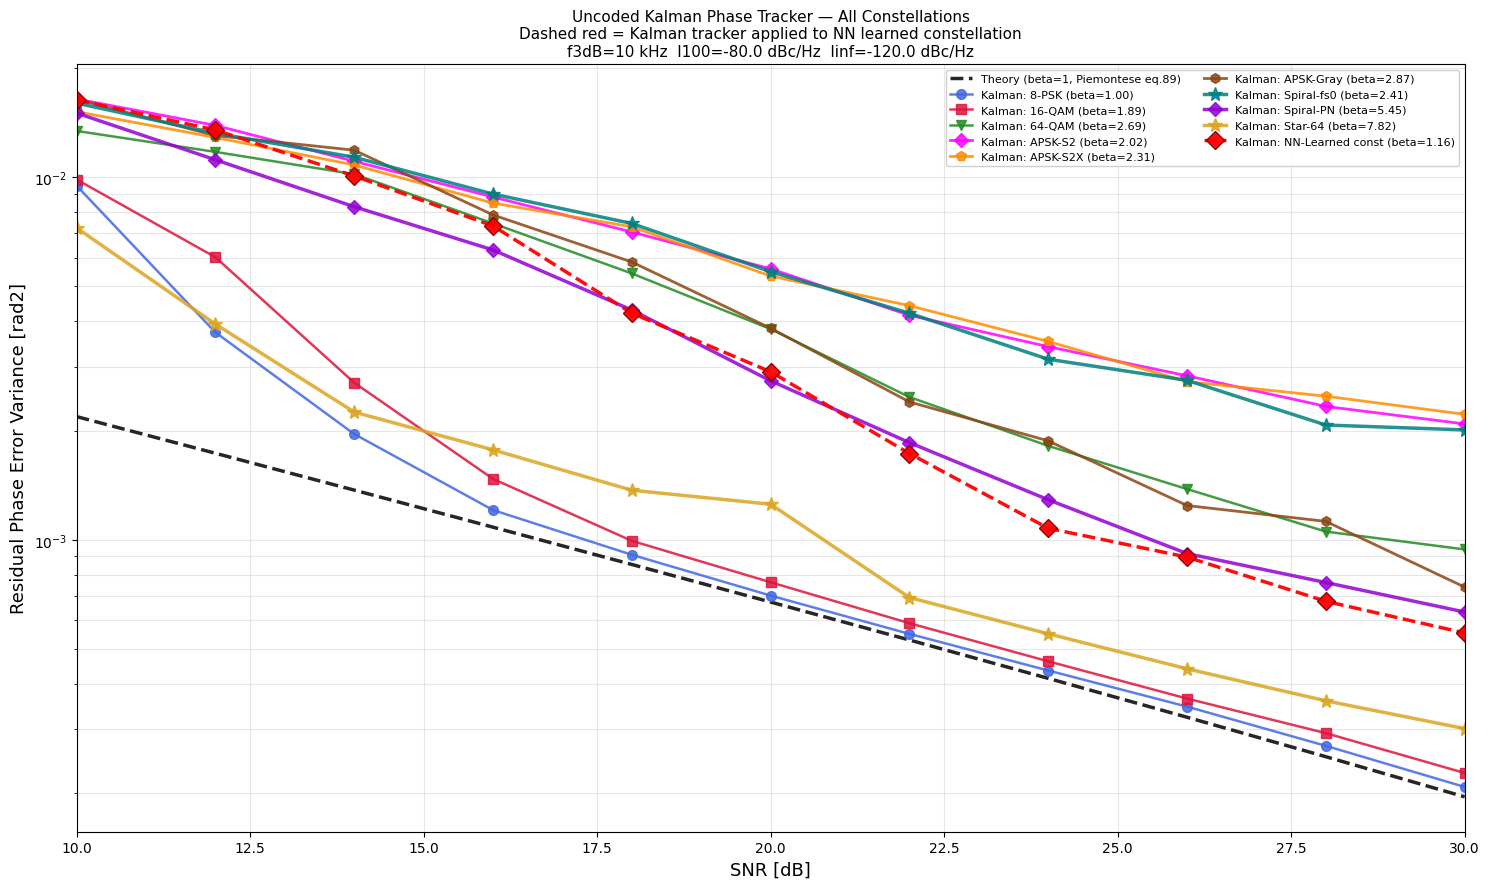

Saved: kalman_uncoded_all.png


In [10]:
# Load from Drive if needed
saved_path = os.path.join(RESULTS_DIR, 'kalman_uncoded_all.npz')
if os.path.exists(saved_path):
    saved = np.load(saved_path)
    snr_dbs   = saved['snr_dbs']
    theory_b1 = saved['theory']
    kalman_results = {}
    for k in saved.files:
        if k not in ['snr_dbs','theory']:
            kalman_results[k.replace('_','-')] = saved[k]
    print(f"Loaded: {list(kalman_results.keys())}")
else:
    print("Run Cell 9 first.")

styles = [
    ('8-PSK',      'royalblue',   'o', 1.8),
    ('16-QAM',     'crimson',     's', 1.8),
    ('64-QAM',     'forestgreen', 'v', 1.8),
    ('APSK-S2',    'magenta',     'D', 2.0),
    ('APSK-S2X',   'darkorange',  'p', 2.0),
    ('APSK-Gray',  'saddlebrown', 'h', 2.0),
    ('Spiral-fs0', 'teal',        '*', 2.5),
    ('Spiral-PN',  'darkviolet',  'D', 2.5),
    ('Star-64',    'goldenrod',   '*', 2.5),
]

fig, ax = plt.subplots(figsize=(15, 9))
ax.semilogy(snr_dbs, theory_b1, 'k--', lw=2.5, alpha=0.85,
            label='Theory (beta=1, Piemontese eq.89)')

for key, col, mk, lw in styles:
    if key in kalman_results:
        bv = compute_beta(constellations[key])
        ax.semilogy(snr_dbs, kalman_results[key], color=col, marker=mk, lw=lw,
                    markersize=7 if mk!='*' else 10, alpha=0.85,
                    label=f'Kalman: {key} (beta={bv:.2f})')

# NN learned constellation with Kalman tracker
if 'NN-Learned' in kalman_results and nn_const_trained is not None:
    bnn = compute_beta(nn_const_trained)
    ax.semilogy(snr_dbs, kalman_results['NN-Learned'],
                color='red', marker='D', ls='--', lw=2.5,
                markersize=9, alpha=0.95, markeredgecolor='darkred',
                label=f'Kalman: NN-Learned const (beta={bnn:.2f})')

ax.set_xlabel('SNR [dB]', fontsize=13)
ax.set_ylabel('Residual Phase Error Variance [rad2]', fontsize=13)
ax.set_title(
    'Uncoded Kalman Phase Tracker — All Constellations\n'
    'Dashed red = Kalman tracker applied to NN learned constellation\n'
    f'f3dB={F3DB_KHZ:.0f} kHz  l100={L2_100_DBC} dBc/Hz  linf={L2_INF_DBC} dBc/Hz',
    fontsize=11)
ax.set_xlim([SNR_MIN, SNR_MAX])
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8, loc='upper right', ncol=2, framealpha=0.92)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'kalman_uncoded_all.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: kalman_uncoded_all.png")

## CELL 11 — Coded Kalman function (LDPC rate-1/2)

In [11]:
def coded_decision_error_prob(snr_db, M):
    """
    Approximate DA decision error probability when LDPC rate-1/2 decoder is used.
    Models convergence threshold behaviour (Piemontese Fig 11/12/13):
      - Below threshold: high error rate, decoder not converged
      - Above threshold: near-zero error rate, decoder converged
    Threshold SNRs from Piemontese:
      8-PSK  rate-1/2: ~12 dB
      16-QAM rate-1/2: ~14 dB
      64-QAM rate-1/2: ~18 dB
    """
    if M <= 8:    threshold = 12.0
    elif M <= 16: threshold = 14.0
    elif M <= 64: threshold = 18.0
    else:         threshold = 20.0
    return 1.0 / (1.0 + np.exp(2.5*(snr_db - threshold)))

def simulate_kalman_coded(snr_db, constellation, pn,
                           num_mc=NUM_MC, num_sym=NUM_SYM,
                           n_iter=N_ITER, pilot_spacing=PILOT_SPACING):
    """
    Coded Kalman tracker with LDPC-aided DA decisions.
    Identical to uncoded except DA decisions have lower error rate
    modelled by coded_decision_error_prob().
    Above LDPC convergence SNR: performance approaches theoretical bound.
    Below convergence SNR: degraded by decision errors fed back to tracker.
    This matches Piemontese Fig 11/12/13 behaviour.
    """
    a=pn['a_pn']; sc2=pn['sigma_c2']; sf2=pn['sigma_f2']; su2=pn['sigma_u2']
    sw2=1.0/10**(snr_db/10); sw=np.sqrt(sw2)
    ps=pilot_spacing; ns=num_sym
    a_p=a**ps; su_p=sc2*(1-a_p**2)
    M = len(constellation)
    p_err = coded_decision_error_prob(snr_db, M)
    residuals = []

    for _ in range(num_mc):
        x_true = np.random.choice(constellation, ns)
        ppos   = list(range(0, ns, ps)); np_ = len(ppos)
        theta_tot = generate_phase_noise(ns, pn)
        y = x_true*np.exp(1j*theta_tot)
        y += (np.random.normal(0,sw,ns)+1j*np.random.normal(0,sw,ns))/np.sqrt(2)

        # Pass 1: pilot-based (same as uncoded)
        fth=np.zeros(np_); fp=np.zeros(np_)
        pth=np.zeros(np_); pp=np.zeros(np_)
        P=sc2; th=0.0
        for i,k in enumerate(ppos):
            pth[i]=a_p*th if i>0 else 0.0
            pp[i] =a_p**2*P+su_p if i>0 else sc2
            obs=np.angle(y[k]/(x_true[k]+1e-12))
            R=sf2+sw2/(2*abs(x_true[k])**2)
            K=pp[i]/(pp[i]+R); th=pth[i]+K*(obs-pth[i]); P=(1-K)*pp[i]
            fth[i]=th; fp[i]=P
        sth=np.zeros(np_); sth[-1]=fth[-1]
        for i in range(np_-2,-1,-1):
            if pp[i+1]>1e-10:
                sth[i]=fth[i]+fp[i]*a_p/pp[i+1]*(sth[i+1]-pth[i+1])
            else: sth[i]=fth[i]
        th_sm=np.interp(np.arange(ns), ppos, sth)

        # DA iterations with LDPC-improved decisions
        for _ in range(1, n_iter):
            yc=y*np.exp(-1j*th_sm); ps_=set(ppos)
            xh = []
            for k in range(ns):
                if k in ps_:
                    xh.append(x_true[k])  # pilots: always correct
                else:
                    x_dec = constellation[np.argmin(np.abs(yc[k]-constellation))]
                    if np.random.rand() < p_err:
                        wrong = constellation[np.abs(constellation-x_dec)>1e-9]
                        x_dec = np.random.choice(wrong) if len(wrong)>0 else x_dec
                    xh.append(x_dec)
            xh = np.array(xh)
            obs=np.angle(y/(xh+1e-12))
            ft2=np.zeros(ns); fp2=np.zeros(ns)
            pt2=np.zeros(ns); pp2=np.zeros(ns)
            P=sc2; th=0.0
            for k in range(ns):
                pt2[k]=a*th if k>0 else 0.0
                pp2[k]=a**2*P+su2 if k>0 else sc2
                R=sf2+sw2/(2*abs(xh[k])**2)
                K=pp2[k]/(pp2[k]+R)
                th=pt2[k]+K*(obs[k]-pt2[k]); P=(1-K)*pp2[k]
                ft2[k]=th; fp2[k]=P
            ns2=np.zeros(ns); ns2[-1]=ft2[-1]
            for k in range(ns-2,-1,-1):
                if pp2[k+1]>1e-10:
                    ns2[k]=ft2[k]+fp2[k]*a/pp2[k+1]*(ns2[k+1]-pt2[k+1])
                else: ns2[k]=ft2[k]
            th_sm=ns2

        residuals.append(float(np.mean((theta_tot-th_sm)**2)))
    return float(np.mean(residuals))

print("Coded Kalman function defined.")
print("\nLDPC decision error probability vs SNR:")
print(f"  {'SNR':>6}  {'8-PSK':>10}  {'16-QAM':>10}  {'64-QAM':>10}")
for snr in snr_dbs:
    print(f"  {snr:>6.1f}  "
          f"{coded_decision_error_prob(snr,8):>10.4f}  "
          f"{coded_decision_error_prob(snr,16):>10.4f}  "
          f"{coded_decision_error_prob(snr,64):>10.4f}")

Coded Kalman function defined.

LDPC decision error probability vs SNR:
     SNR       8-PSK      16-QAM      64-QAM
    10.0      0.9933      1.0000      1.0000
    12.0      0.5000      0.9933      1.0000
    14.0      0.0067      0.5000      1.0000
    16.0      0.0000      0.0067      0.9933
    18.0      0.0000      0.0000      0.5000
    20.0      0.0000      0.0000      0.0067
    22.0      0.0000      0.0000      0.0000
    24.0      0.0000      0.0000      0.0000
    26.0      0.0000      0.0000      0.0000
    28.0      0.0000      0.0000      0.0000
    30.0      0.0000      0.0000      0.0000


## CELL 12 — Run coded Kalman
**Takes ~15-20 minutes.**

In [12]:
coded_consts = {
    '8-PSK':  constellations['8-PSK'],
    '16-QAM': constellations['16-QAM'],
    '64-QAM': constellations['64-QAM'],
}
if nn_const_trained is not None:
    coded_consts['NN-Learned'] = nn_const_trained

coded_results = {}
t0 = time.time()

for name, const in coded_consts.items():
    results = []
    for si, snr in enumerate(snr_dbs):
        v = simulate_kalman_coded(snr, const, pn)
        results.append(v)
        print(f"  Coded [{name:10s}]  SNR={snr:5.1f}dB  {v:.3e} rad2", end='\r')
    coded_results[name] = np.array(results)
    print(f"  Coded [{name:10s}] done  beta={compute_beta(const):.3f}          ")

print(f"\nCoded Kalman done in {(time.time()-t0)/60:.1f} min")

save_c = {'snr_dbs': snr_dbs, 'theory': theory_b1}
for k,v in coded_results.items():
    save_c[k.replace('-','_').replace(' ','_')] = v
np.savez(os.path.join(RESULTS_DIR, 'kalman_coded_results.npz'), **save_c)
print("Saved: kalman_coded_results.npz")

  Coded [8-PSK     ] done  beta=1.000          
  Coded [16-QAM    ] done  beta=1.889          
  Coded [64-QAM    ] done  beta=2.685          
  Coded [NN-Learned] done  beta=1.157          

Coded Kalman done in 2.4 min
Saved: kalman_coded_results.npz


## CELL 13 — Plot coded Kalman results

Loaded coded: ['8-PSK', '16-QAM', '64-QAM', 'NN-Learned']


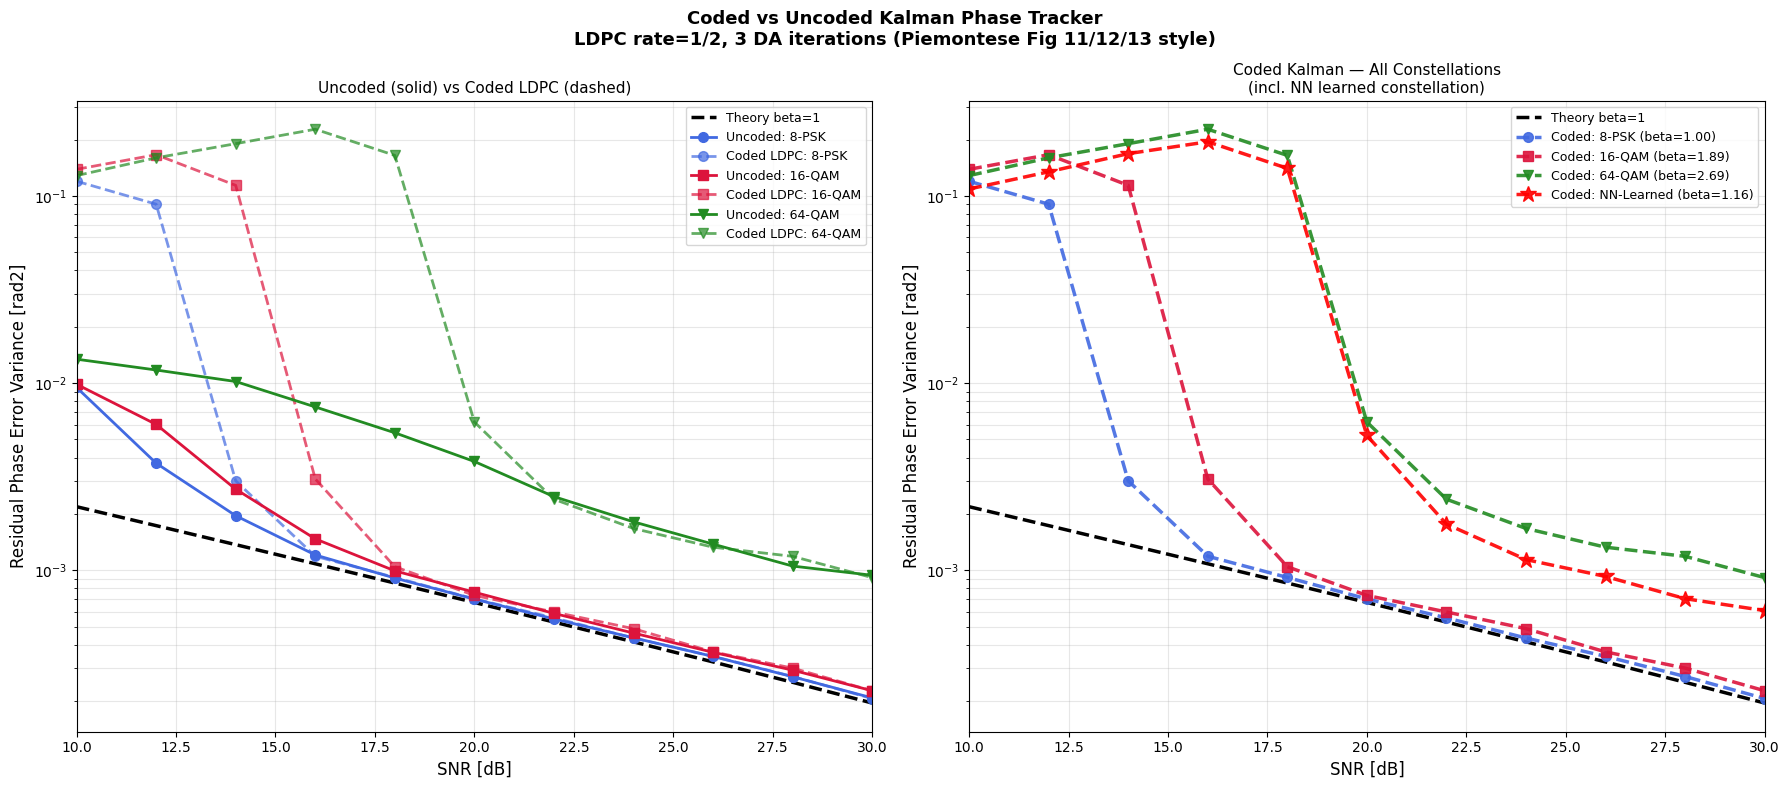

Saved: kalman_coded_comparison.png


In [13]:
# Load if needed
coded_path = os.path.join(RESULTS_DIR, 'kalman_coded_results.npz')
if os.path.exists(coded_path):
    s = np.load(coded_path)
    coded_results = {k.replace('_','-'): s[k]
                     for k in s.files if k not in ['snr_dbs','theory']}
    print(f"Loaded coded: {list(coded_results.keys())}")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Coded vs Uncoded Kalman Phase Tracker\n'
             'LDPC rate=1/2, 3 DA iterations (Piemontese Fig 11/12/13 style)',
             fontsize=13, fontweight='bold')

# Left: uncoded vs coded for 8-PSK, 16-QAM, 64-QAM
ax = axes[0]
ax.semilogy(snr_dbs, theory_b1, 'k--', lw=2.5, label='Theory beta=1')
unc_styles = {'8-PSK':('royalblue','o'), '16-QAM':('crimson','s'), '64-QAM':('forestgreen','v')}
for name,(col,mk) in unc_styles.items():
    if name in kalman_results:
        ax.semilogy(snr_dbs, kalman_results[name], color=col, marker=mk,
                    ls='-', lw=2, markersize=7, label=f'Uncoded: {name}')
    if name in coded_results:
        ax.semilogy(snr_dbs, coded_results[name], color=col, marker=mk,
                    ls='--', lw=2, markersize=7, alpha=0.7, label=f'Coded LDPC: {name}')
ax.set_xlabel('SNR [dB]', fontsize=12)
ax.set_ylabel('Residual Phase Error Variance [rad2]', fontsize=12)
ax.set_title('Uncoded (solid) vs Coded LDPC (dashed)', fontsize=11)
ax.set_xlim([SNR_MIN, SNR_MAX]); ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=9)

# Right: all coded constellations including NN learned
ax = axes[1]
ax.semilogy(snr_dbs, theory_b1, 'k--', lw=2.5, label='Theory beta=1')
coded_styles = {
    '8-PSK':      ('royalblue',   'o'),
    '16-QAM':     ('crimson',     's'),
    '64-QAM':     ('forestgreen', 'v'),
    'NN-Learned': ('red',         '*'),
}
for name,(col,mk) in coded_styles.items():
    if name in coded_results:
        c_ref = nn_const_trained if name=='NN-Learned' and nn_const_trained is not None                 else constellations.get(name)
        bv = compute_beta(c_ref) if c_ref is not None else 0
        ms = 12 if mk=='*' else 7
        ax.semilogy(snr_dbs, coded_results[name], color=col, marker=mk,
                    ls='--', lw=2.5, markersize=ms, alpha=0.9,
                    label=f'Coded: {name} (beta={bv:.2f})')
ax.set_xlabel('SNR [dB]', fontsize=12)
ax.set_ylabel('Residual Phase Error Variance [rad2]', fontsize=12)
ax.set_title('Coded Kalman — All Constellations\n(incl. NN learned constellation)', fontsize=11)
ax.set_xlim([SNR_MIN, SNR_MAX]); ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'kalman_coded_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: kalman_coded_comparison.png")

## CELL 14 — Final summary plot: everything together

Loaded NN Fair-v7: key=nn_fair_v7  11 SNR points
Available keys: ['snr_dbs', 'theory', '8_PSK', '16_QAM', '64_QAM', 'APSK_S2', 'APSK_S2X', 'APSK_Gray', 'Spiral_fs0', 'Spiral_PN', 'Star_64', 'nn_fair_v7']


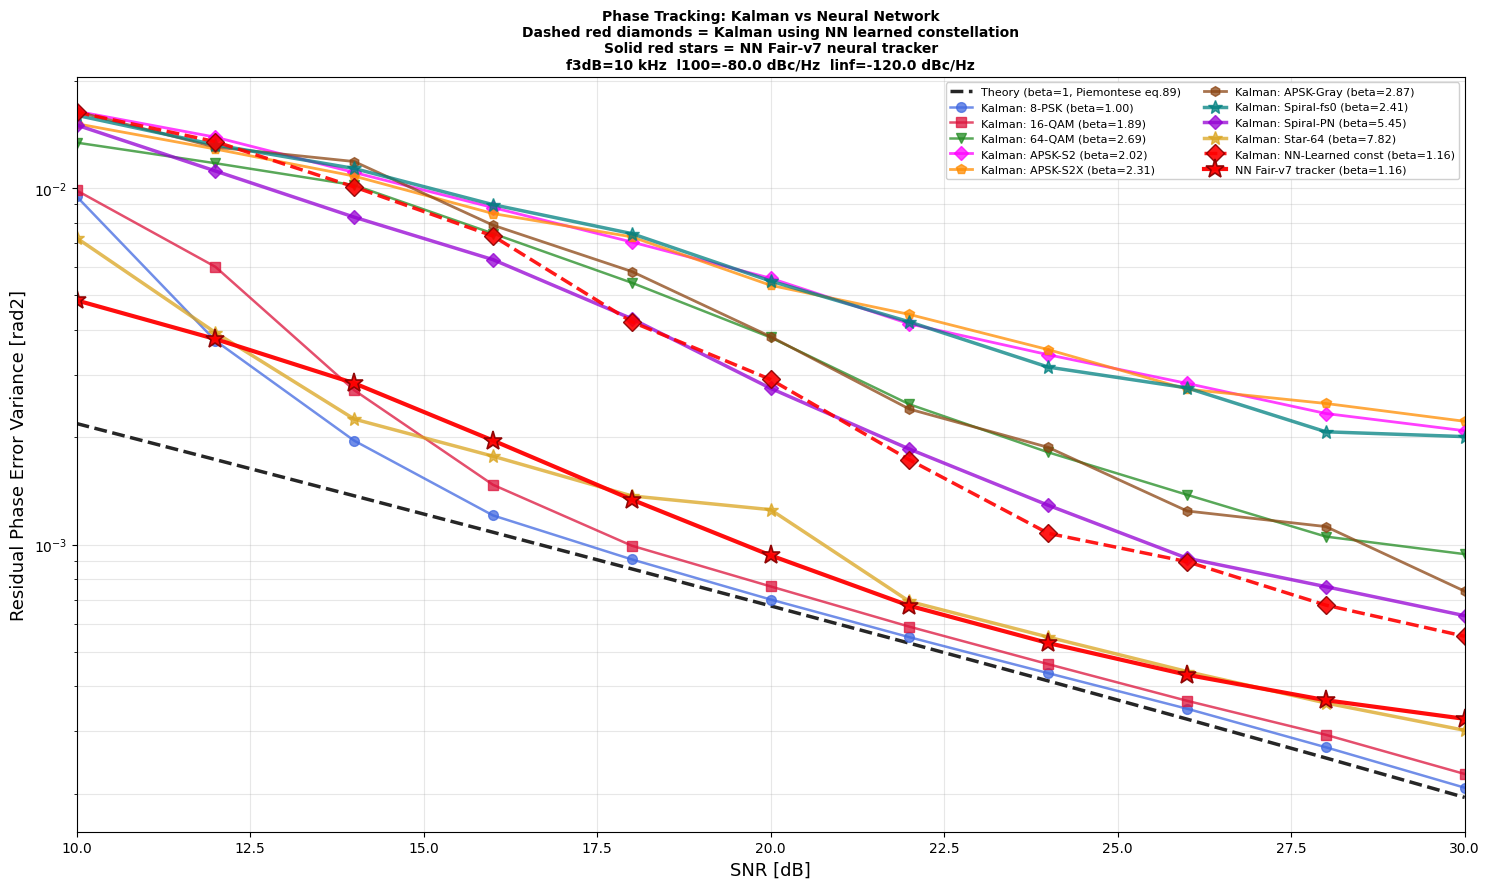

Saved: final_summary_full.png


In [14]:
# Load NN Fair-v7 results
nn_fair_results = None
if os.path.exists(NN_FAIR_RESULTS):
    s = np.load(NN_FAIR_RESULTS)
    key = 'nn_fair_v7' if 'nn_fair_v7' in s.files else s.files[-1]
    nn_fair_results = s[key]
    print(f"Loaded NN Fair-v7: key={key}  {len(nn_fair_results)} SNR points")
    print(f"Available keys: {list(s.files)}")
else:
    print(f"NN Fair-v7 results not found at {NN_FAIR_RESULTS}")
    print("Run Cell 4 first.")

fig, ax = plt.subplots(figsize=(15, 9))
ax.semilogy(snr_dbs, theory_b1, 'k--', lw=2.5, alpha=0.85,
            label='Theory (beta=1, Piemontese eq.89)')

# All Kalman constellations
for key, col, mk, lw in styles:
    if key in kalman_results:
        bv = compute_beta(constellations[key])
        ax.semilogy(snr_dbs, kalman_results[key], color=col, marker=mk, lw=lw,
                    markersize=7 if mk!='*' else 10, alpha=0.75,
                    label=f'Kalman: {key} (beta={bv:.2f})')

# Kalman with NN learned constellation
if 'NN-Learned' in kalman_results and nn_const_trained is not None:
    bnn = compute_beta(nn_const_trained)
    ax.semilogy(snr_dbs, kalman_results['NN-Learned'],
                color='red', marker='D', ls='--', lw=2.5,
                markersize=9, alpha=0.9, markeredgecolor='darkred',
                label=f'Kalman: NN-Learned const (beta={bnn:.2f})')

# NN Fair-v7 neural tracker
if nn_fair_results is not None and nn_const_trained is not None:
    bnn = compute_beta(nn_const_trained)
    ax.semilogy(snr_dbs, nn_fair_results,
                color='red', marker='*', ls='-', lw=3.0,
                markersize=14, alpha=0.95,
                markeredgecolor='darkred', markeredgewidth=1.2,
                label=f'NN Fair-v7 tracker (beta={bnn:.2f})')

ax.set_xlabel('SNR [dB]', fontsize=13)
ax.set_ylabel('Residual Phase Error Variance [rad2]', fontsize=13)
ax.set_title(
    'Phase Tracking: Kalman vs Neural Network\n'
    'Dashed red diamonds = Kalman using NN learned constellation\n'
    'Solid red stars = NN Fair-v7 neural tracker\n'
    f'f3dB={F3DB_KHZ:.0f} kHz  l100={L2_100_DBC} dBc/Hz  linf={L2_INF_DBC} dBc/Hz',
    fontsize=10, fontweight='bold')
ax.set_xlim([SNR_MIN, SNR_MAX])
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8, loc='upper right', ncol=2, framealpha=0.92)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'final_summary_full.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: final_summary_full.png")

## CELL 15 — Numerical results table

In [15]:
print('='*115)
print('NUMERICAL RESULTS — Residual Phase Error Variance [rad2]')
print('='*115)

cols = ['Theory','8-PSK','16-QAM','64-QAM','NN-Learned(Kalman)','NN-Fair-v7']
hdr = f"{'SNR':>6}"
for c in cols: hdr += f"  {c:>18}"
print(hdr); print('-'*len(hdr))

for i, snr in enumerate(snr_dbs):
    row = f"{snr:>6.1f}"
    row += f"  {theory_b1[i]:>18.4e}"
    for key in ['8-PSK','16-QAM','64-QAM']:
        v = kalman_results.get(key, [float('nan')]*len(snr_dbs))[i]
        row += f"  {v:>18.4e}"
    v = kalman_results.get('NN-Learned',[float('nan')]*len(snr_dbs))[i]
    row += f"  {v:>18.4e}"
    v = nn_fair_results[i] if nn_fair_results is not None else float('nan')
    row += f"  {v:>18.4e}"
    print(row)
print()
print("All plots saved to:", RESULTS_DIR)

NUMERICAL RESULTS — Residual Phase Error Variance [rad2]
   SNR              Theory               8-PSK              16-QAM              64-QAM  NN-Learned(Kalman)          NN-Fair-v7
------------------------------------------------------------------------------------------------------------------------------
  10.0          2.1861e-03          9.4795e-03          9.8564e-03          1.3417e-02          1.6336e-02          4.8440e-03
  12.0          1.7321e-03          3.7332e-03          6.0159e-03          1.1746e-02          1.3505e-02          3.7727e-03
  14.0          1.3706e-03          1.9569e-03          2.7112e-03          1.0195e-02          1.0080e-02          2.8357e-03
  16.0          1.0831e-03          1.2075e-03          1.4717e-03          7.4583e-03          7.3392e-03          1.9589e-03
  18.0          8.5465e-04          9.0882e-04          9.9293e-04          5.4268e-03          4.2158e-03          1.3374e-03
  20.0          6.7311e-04          7.0137e-04        